# Project 11: EleGuard Collision Risk

Proposed-only weak-supervision prototype: **Video ConvLSTM + Spatial GAT + Survival Head**.

The linked YOLO dataset has still images and bounding boxes, not synchronized video/GPS/rail/weather/collision events. This notebook therefore predicts a documented **visual proximity-risk proxy**. Replace the proxy and spatial grid with real timestamps, GPS/rail graph and collision/censoring labels before making collision-risk claims.

## 0. Setup

In [1]:
!pip -q install kagglehub pillow scikit-learn tqdm

import json, os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from tqdm.auto import tqdm
import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Device:", DEVICE)

Device: cuda:0


In [2]:
CONFIG = {
    "dataset_slug": "gunarakulangr/wild-elephant-yolo-format-dataset",
    "max_images": 3000,
    "image_size": 64,
    "frames": 3,
    "batch_size": 32,
    "epochs": 15,
    "patience": 4,
    "learning_rate": 1e-3,
    "results_dir": "data/11/results",
    "figures_dir": "data/11/figures",
}
for key in ("results_dir", "figures_dir"):
    os.makedirs(CONFIG[key], exist_ok=True)
CONFIG

{'dataset_slug': 'gunarakulangr/wild-elephant-yolo-format-dataset',
 'max_images': 3000,
 'image_size': 64,
 'frames': 3,
 'batch_size': 32,
 'epochs': 15,
 'patience': 4,
 'learning_rate': 0.001,
 'results_dir': 'data/11/results',
 'figures_dir': 'data/11/figures'}

## 1. Dataset acquisition

In [3]:
dataset_root = Path(kagglehub.dataset_download(CONFIG["dataset_slug"]))
image_paths = sorted(p for p in dataset_root.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
assert image_paths, f"No images found under {dataset_root}"
if len(image_paths) > CONFIG["max_images"]:
    rng = np.random.default_rng(SEED)
    image_paths = [image_paths[i] for i in sorted(rng.choice(len(image_paths), CONFIG["max_images"], replace=False))]
print("Images selected:", len(image_paths))

  0%|          | 0.00/1.27G [00:00<?, ?B/s]

  0%|          | 1.00M/1.27G [00:00<10:36, 2.14MB/s]

  0%|          | 3.00M/1.27G [00:00<03:54, 5.80MB/s]

  1%|          | 7.00M/1.27G [00:00<01:39, 13.6MB/s]

  1%|          | 10.0M/1.27G [00:00<01:19, 16.9MB/s]

...

 99%|█████████▉| 1.26G/1.27G [00:34<00:00, 35.6MB/s]

100%|█████████▉| 1.27G/1.27G [00:35<00:00, 35.0MB/s]

100%|██████████| 1.27G/1.27G [00:35<00:00, 38.8MB/s]

Extracting files...


Images selected: 3000


## 2. YOLO labels and weak survival target

In [4]:
def label_path_for(image_path):
    candidates = [image_path.with_suffix(".txt")]
    parts = list(image_path.parts)
    if "images" in parts:
        parts[len(parts) - 1 - parts[::-1].index("images")] = "labels"
        candidates.append(Path(*parts).with_suffix(".txt"))
    return next((p for p in candidates if p.exists()), None)

rows = []
for image_path in image_paths:
    label_path = label_path_for(image_path)
    boxes = []
    if label_path:
        for line in label_path.read_text(encoding="utf-8", errors="ignore").splitlines():
            parts = line.split()
            if len(parts) >= 5:
                _, x, y, w, h = map(float, parts[:5]); boxes.append((x, y, w, h))
    if not boxes: continue
    x, y, w, h = max(boxes, key=lambda box: box[2] * box[3])
    area = np.clip(w * h, 0, 1)
    center_weight = np.exp(-4 * ((x - 0.5) ** 2 + (y - 0.5) ** 2))
    risk = np.clip(0.65 * area + 0.35 * center_weight, 1e-4, 0.999)
    proxy_time = -np.log(risk)
    grid_x, grid_y = min(int(x * 4), 3), min(int(y * 4), 3)
    rows.append({"path": str(image_path), "risk": risk, "proxy_time": proxy_time, "node": grid_y * 4 + grid_x})
df = pd.DataFrame(rows)
assert len(df) >= 100, "Too few labelled YOLO images"
df["risk_class"] = (df.risk >= df.risk.median()).astype(int)
print(df[["risk", "proxy_time"]].describe())
# Target sanity check: risk_class is a median split so it is usually balanced by construction,
# but a row-limiting/sorting bug upstream (e.g. truncating image_paths to a sorted block) could
# still collapse it to one class - catch that early.
print("risk_class distribution (counts):"); print(df.risk_class.value_counts())
print("risk_class distribution (normalized):"); print(df.risk_class.value_counts(normalize=True))
assert df.risk_class.nunique() > 1, f"DEGENERATE TARGET: only {df.risk_class.nunique()} unique value(s) found - {df.risk_class.value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
minority_frac=df.risk_class.value_counts(normalize=True).min()
if minority_frac < 0.01 or len(df) < 100:
    print(f"[DATA QUALITY WARNING] rows={len(df)}, minority class fraction={minority_frac:.4f} - check upstream filtering/sampling.")


              risk   proxy_time
count  3000.000000  3000.000000
mean      0.486423     0.778423
std       0.164375     0.346338
min       0.096114     0.001001
25%       0.371696     0.564216
50%       0.463386     0.769194
75%       0.568806     0.989680
max       0.999000     2.342219
risk_class distribution (counts):
risk_class
0    1500
1    1500
Name: count, dtype: int64
risk_class distribution (normalized):
risk_class
0    0.5
1    0.5
Name: proportion, dtype: float64


## 3. Leakage-safe split

In [5]:
indices = np.arange(len(df))
train_idx, rest_idx = train_test_split(indices, train_size=0.70, stratify=df.risk_class, random_state=SEED)
val_idx, test_idx = train_test_split(rest_idx, train_size=0.50, stratify=df.risk_class.iloc[rest_idx], random_state=SEED)
assert set(train_idx).isdisjoint(val_idx) and set(train_idx).isdisjoint(test_idx)
print("Train/val/test:", len(train_idx), len(val_idx), len(test_idx))

adjacency = np.zeros((16, 16), dtype=np.float32)
for y in range(4):
    for x in range(4):
        i = y * 4 + x
        for dy, dx in ((0,0), (1,0), (-1,0), (0,1), (0,-1)):
            yy, xx = y + dy, x + dx
            if 0 <= yy < 4 and 0 <= xx < 4: adjacency[i, yy * 4 + xx] = 1
adjacency /= adjacency.sum(1, keepdims=True)
ADJ = torch.tensor(adjacency, device=DEVICE)

Train/val/test: 2100 450 450


## 4. Proposed model

In [6]:
def image_tensor(image):
    image = image.resize((CONFIG["image_size"], CONFIG["image_size"]))
    array = np.asarray(image, dtype=np.float32) / 255.0
    if array.ndim == 2: array = np.repeat(array[..., None], 3, axis=2)
    return torch.tensor(array[..., :3].transpose(2, 0, 1), dtype=torch.float32)

class ElephantClipDataset(Dataset):
    def __init__(self, indices, augment=False): self.indices = np.asarray(indices); self.augment = augment
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        row = df.iloc[self.indices[i]]; base = Image.open(row.path).convert("RGB")
        frames = [base, ImageOps.mirror(base), ImageEnhance.Brightness(base).enhance(0.85)]
        if self.augment and random.random() < 0.5: frames = list(reversed(frames))
        clip = torch.stack([image_tensor(frame) for frame in frames[:CONFIG["frames"]]])
        return clip, torch.tensor(row.node), torch.tensor(row.proxy_time, dtype=torch.float32), torch.tensor(row.risk_class, dtype=torch.float32)

train_loader = DataLoader(ElephantClipDataset(train_idx, True), CONFIG["batch_size"], shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(ElephantClipDataset(val_idx), CONFIG["batch_size"], num_workers=2, pin_memory=True)
test_loader = DataLoader(ElephantClipDataset(test_idx), CONFIG["batch_size"], num_workers=2, pin_memory=True)

In [7]:
class ConvLSTMCell(nn.Module):
    def __init__(self, channels):
        super().__init__(); self.gates = nn.Conv2d(channels * 2, channels * 4, 3, padding=1)
    def forward(self, x, state):
        h, c = state; i, f, o, g = self.gates(torch.cat([x, h], 1)).chunk(4, 1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        return torch.sigmoid(o) * torch.tanh(c), c

class SpatialGAT(nn.Module):
    def __init__(self, hidden=32):
        super().__init__(); self.nodes = nn.Parameter(torch.randn(16, hidden) * 0.1); self.q = nn.Linear(hidden, hidden); self.k = nn.Linear(hidden, hidden); self.v = nn.Linear(hidden, hidden)
    def forward(self, node_id):
        scores = self.q(self.nodes) @ self.k(self.nodes).T / self.nodes.shape[1] ** 0.5
        scores = scores.masked_fill(ADJ == 0, -1e4)
        graph = torch.softmax(scores, -1) @ self.v(self.nodes)
        return graph[node_id]

class EleGuardProposed(nn.Module):
    def __init__(self):
        super().__init__()
        self.frame_encoder = nn.Sequential(nn.Conv2d(3, 24, 5, stride=2, padding=2), nn.ReLU(), nn.Conv2d(24, 32, 3, stride=2, padding=1), nn.ReLU())
        self.temporal = ConvLSTMCell(32); self.graph = SpatialGAT(32)
        self.fusion = nn.Sequential(nn.Linear(64, 48), nn.ReLU(), nn.Dropout(0.2))
        self.survival_head = nn.Linear(48, 1); self.risk_head = nn.Linear(48, 1)
    def forward(self, clip, node_id):
        b = clip.shape[0]; h = c = torch.zeros(b, 32, CONFIG["image_size"] // 4, CONFIG["image_size"] // 4, device=clip.device)
        for t in range(clip.shape[1]): h, c = self.temporal(self.frame_encoder(clip[:, t]), (h, c))
        visual = h.mean((2, 3)); fused = self.fusion(torch.cat([visual, self.graph(node_id)], 1))
        return F.softplus(self.survival_head(fused)).squeeze(1), self.risk_head(fused).squeeze(1)

model = EleGuardProposed().to(DEVICE)
print(model); print("Parameters:", sum(p.numel() for p in model.parameters()))

EleGuardProposed(
  (frame_encoder): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (temporal): ConvLSTMCell(
    (gates): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (graph): SpatialGAT(
    (q): Linear(in_features=32, out_features=32, bias=True)
    (k): Linear(in_features=32, out_features=32, bias=True)
    (v): Linear(in_features=32, out_features=32, bias=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=64, out_features=48, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (survival_head): Linear(in_features=48, out_features=1, bias=True)
  (risk_head): Linear(in_features=48, out_features=1, bias=True)
)
Parameters: 89522


## 5. Training

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-4)
history = {"train_loss": [], "val_loss": []}; best = float("inf"); stale = 0

def epoch(loader, training):
    model.train(training); total = 0.0
    for clip, node, proxy_time, risk_class in loader:
        clip, node, proxy_time, risk_class = clip.to(DEVICE), node.to(DEVICE), proxy_time.to(DEVICE), risk_class.to(DEVICE)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            pred_time, risk_logit = model(clip, node)
            loss = F.smooth_l1_loss(pred_time, proxy_time) + 0.3 * F.binary_cross_entropy_with_logits(risk_logit, risk_class)
            if training: loss.backward(); optimizer.step()
        total += loss.item() * len(clip)
    return total / len(loader.dataset)

for step in tqdm(range(CONFIG["epochs"]), desc="Training"):
    train_loss = epoch(train_loader, True); val_loss = epoch(val_loader, False)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    if val_loss < best:
        best = val_loss; stale = 0; torch.save(model.state_dict(), Path(CONFIG["results_dir"]) / "best_proposed.pt")
    else:
        stale += 1
        if stale >= CONFIG["patience"]: break
model.load_state_dict(torch.load(Path(CONFIG["results_dir"]) / "best_proposed.pt", map_location=DEVICE, weights_only=True))

Training:   0%|          | 0/15 [00:00<?, ?it/s]

<All keys matched successfully>

## 6. Evaluation

In [9]:
model.eval(); predicted_time = []; actual_time = []; risk_prob = []; risk_y = []
with torch.no_grad():
    for clip, node, proxy_time, risk_class in test_loader:
        pred_time, risk_logit = model(clip.to(DEVICE), node.to(DEVICE))
        predicted_time.append(pred_time.cpu().numpy()); actual_time.append(proxy_time.numpy())
        risk_prob.append(torch.sigmoid(risk_logit).cpu().numpy()); risk_y.append(risk_class.numpy())
predicted_time, actual_time = np.concatenate(predicted_time), np.concatenate(actual_time)
risk_prob, risk_y = np.concatenate(risk_prob), np.concatenate(risk_y)
metrics = {
    "proxy_time_mae": mean_absolute_error(actual_time, predicted_time),
    "proxy_time_rmse": mean_squared_error(actual_time, predicted_time) ** 0.5,
    "proxy_time_r2": r2_score(actual_time, predicted_time),
    "proxy_risk_accuracy": accuracy_score(risk_y, risk_prob >= 0.5),
}
Path(CONFIG["results_dir"], "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(json.dumps(metrics, indent=2))

{
  "proxy_time_mae": 0.19545027613639832,
  "proxy_time_rmse": 0.25713923716409626,
  "proxy_time_r2": 0.4029460549354553,
  "proxy_risk_accuracy": 0.7288888888888889
}


## 7. Figures and error analysis

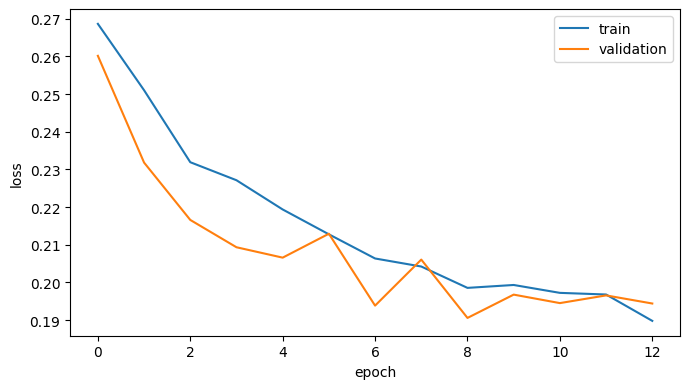

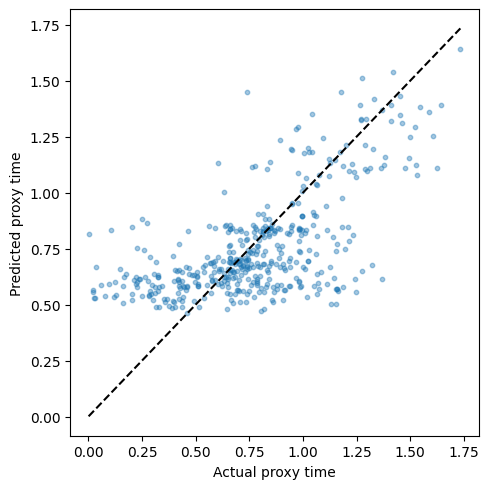

,image,absolute_error
0,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.813363
1,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.754947
2,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.731643
3,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.710502
4,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.692243
5,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.650005
6,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.647019
7,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.641087
8,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.633796
9,/root/.cache/kagglehub/datasets/gunarakulangr/...,0.629662


In [10]:
plt.figure(figsize=(7,4)); plt.plot(history["train_loss"], label="train"); plt.plot(history["val_loss"], label="validation"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss"); plt.tight_layout(); plt.savefig(Path(CONFIG["figures_dir"]) / "fig01_loss.png", dpi=180); plt.show()
plt.figure(figsize=(5,5)); plt.scatter(actual_time, predicted_time, s=10, alpha=0.4); lo, hi = min(actual_time.min(), predicted_time.min()), max(actual_time.max(), predicted_time.max()); plt.plot([lo,hi],[lo,hi],"k--"); plt.xlabel("Actual proxy time"); plt.ylabel("Predicted proxy time"); plt.tight_layout(); plt.savefig(Path(CONFIG["figures_dir"]) / "fig02_proxy_time.png", dpi=180); plt.show()
errors = np.abs(actual_time - predicted_time); worst = np.argsort(errors)[-10:][::-1]
display(pd.DataFrame({"image": df.iloc[test_idx[worst]].path.to_numpy(), "absolute_error": errors[worst]}))